# CIFAR-100 Image Classification with CNN
## Deep Learning Course Assignment

This notebook trains a Convolutional Neural Network on a subset of the CIFAR-100 dataset.
We experiment with various hyperparameters to improve classification accuracy.

**Dataset:** CIFAR-100, 10 classes selected (classes 0-9)
**Framework:** PyTorch
**Hardware:** AMD MI300X GPU (AMD Developer Cloud)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torchvision
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
GPU available: True
GPU: Tesla T4


## 1. Data Loading and Preprocessing

We load CIFAR-100 and filter to 10 classes (indices 0-9):
apple, aquarium_fish, baby, bear, beaver, bed, bee, beetle, bicycle, bottle

These classes were chosen as they are visually distinct from each other,
making them a reasonable baseline for a 10-class classification problem.

In [2]:
# Load CIFAR-100 dataset
trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True)
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True)

X_train = np.array(trainset.data)
y_train = np.array(trainset.targets)
X_test = np.array(testset.data)
y_test = np.array(testset.targets)

# Filter to 10 classes
selected_classes = np.arange(10)
class_names = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver',
               'bed', 'bee', 'beetle', 'bicycle', 'bottle']

train_mask = np.isin(y_train, selected_classes)
X_train, y_train = X_train[train_mask], y_train[train_mask]

test_mask = np.isin(y_test, selected_classes)
X_test, y_test = X_test[test_mask], y_test[test_mask]

# Normalize pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Image shape: {X_train[0].shape}")

100%|██████████| 169M/169M [00:03<00:00, 42.5MB/s]


Training samples: 5000
Test samples: 1000
Image shape: (32, 32, 3)


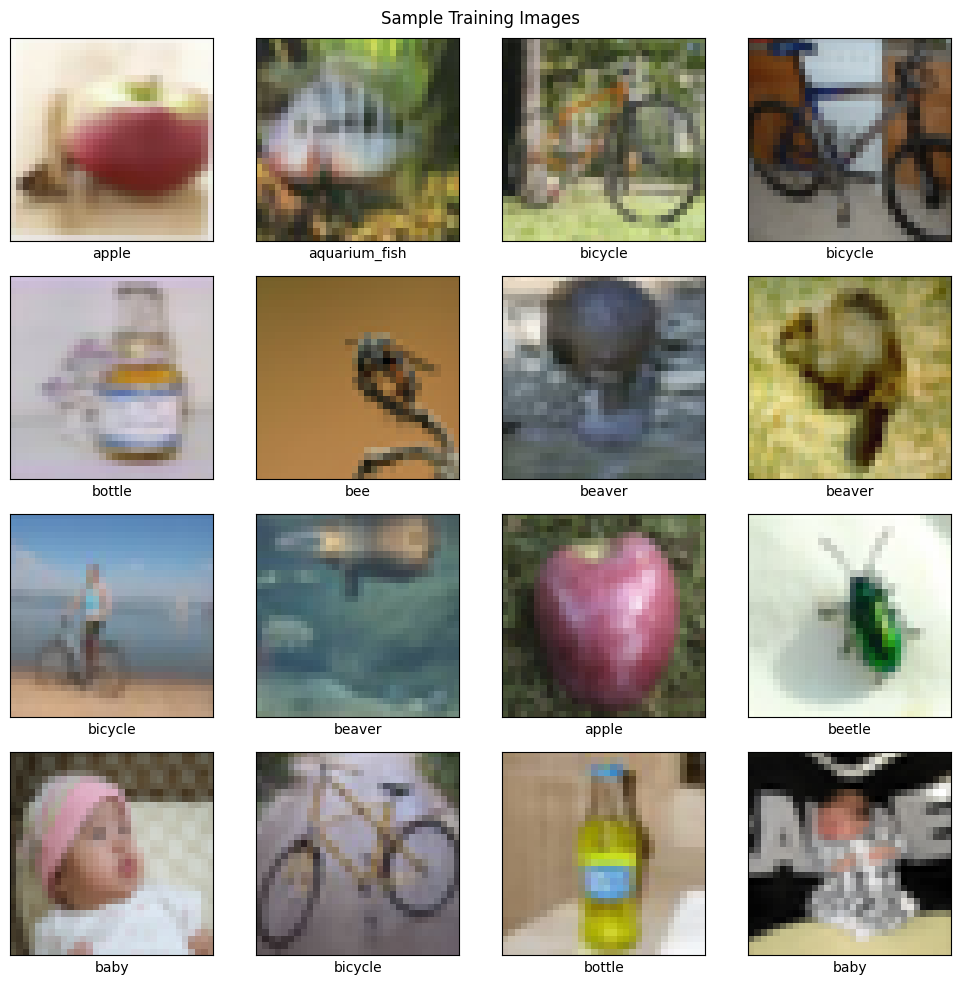

In [3]:
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.xlabel(class_names[y_train[i]])
plt.suptitle('Sample Training Images')
plt.tight_layout()
plt.show()

In [4]:
X_train_t = torch.tensor(X_train).permute(0, 3, 1, 2)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test).permute(0, 3, 1, 2)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

Training on: cuda


## 2. Baseline Model

Architecture:
- 3 convolutional blocks with increasing filters: 32 → 64 → 128
- Each block: Conv2D → ReLU → Conv2D → ReLU → MaxPool2D → Dropout(0.25)
- Flatten → Dense(512) → ReLU → Dropout(0.5) → Dense(10)
- Optimizer: Adam, lr=0.001
- Batch size: 64
- Epochs: 30

In [5]:
class CNN(nn.Module):
    def __init__(self, activation=nn.ReLU):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, (3, 3), padding=1), activation(),
            nn.Conv2d(32, 32, (3, 3), padding=1), activation(),
            nn.MaxPool2d((2, 2)), nn.Dropout2d(0.25),

            nn.Conv2d(32, 64, (3, 3), padding=1), activation(),
            nn.Conv2d(64, 64, (3, 3), padding=1), activation(),
            nn.MaxPool2d((2, 2)), nn.Dropout2d(0.25),

            nn.Conv2d(64, 128, (3, 3), padding=1), activation(),
            nn.Conv2d(128, 128, (3, 3), padding=1), activation(),
            nn.MaxPool2d((2, 2)), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 512), activation(),
            nn.Dropout(0.5),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [6]:
def train_model(model, train_loader, test_loader, optimizer, epochs=30):
    criterion = nn.CrossEntropyLoss()
    train_accs, val_accs, train_losses, val_losses = [], [], [], []

    for epoch in range(epochs):
        model.train()
        correct, total, running_loss = 0, 0, 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            correct += (outputs.argmax(1) == y_batch).sum().item()
            total += y_batch.size(0)
        train_accs.append(correct / total)
        train_losses.append(running_loss / len(train_loader))

        model.eval()
        correct, total, running_loss = 0, 0, 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                running_loss += loss.item()
                correct += (outputs.argmax(1) == y_batch).sum().item()
                total += y_batch.size(0)
        val_accs.append(correct / total)
        val_losses.append(running_loss / len(test_loader))
        print(f"Epoch {epoch+1}/{epochs} | Train acc: {train_accs[-1]:.4f} | Val acc: {val_accs[-1]:.4f}")

    return train_accs, val_accs, train_losses, val_losses

def plot_results(train_accs, val_accs, train_losses, val_losses, title):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()
    print(f"Final test accuracy: {val_accs[-1]*100:.2f}%")

Epoch 1/30 | Train acc: 0.1362 | Val acc: 0.2070
Epoch 2/30 | Train acc: 0.2562 | Val acc: 0.2960
Epoch 3/30 | Train acc: 0.3386 | Val acc: 0.3950
Epoch 4/30 | Train acc: 0.3990 | Val acc: 0.4670
Epoch 5/30 | Train acc: 0.4606 | Val acc: 0.4480
Epoch 6/30 | Train acc: 0.4758 | Val acc: 0.5310
Epoch 7/30 | Train acc: 0.5188 | Val acc: 0.5620
Epoch 8/30 | Train acc: 0.5408 | Val acc: 0.5160
Epoch 9/30 | Train acc: 0.5646 | Val acc: 0.5730
Epoch 10/30 | Train acc: 0.5934 | Val acc: 0.5840
Epoch 11/30 | Train acc: 0.6062 | Val acc: 0.5810
Epoch 12/30 | Train acc: 0.6272 | Val acc: 0.5760
Epoch 13/30 | Train acc: 0.6396 | Val acc: 0.6120
Epoch 14/30 | Train acc: 0.6586 | Val acc: 0.6130
Epoch 15/30 | Train acc: 0.6666 | Val acc: 0.5880
Epoch 16/30 | Train acc: 0.6908 | Val acc: 0.6180
Epoch 17/30 | Train acc: 0.7108 | Val acc: 0.6140
Epoch 18/30 | Train acc: 0.7128 | Val acc: 0.6330
Epoch 19/30 | Train acc: 0.7446 | Val acc: 0.6320
Epoch 20/30 | Train acc: 0.7498 | Val acc: 0.6280
Epoch 21/

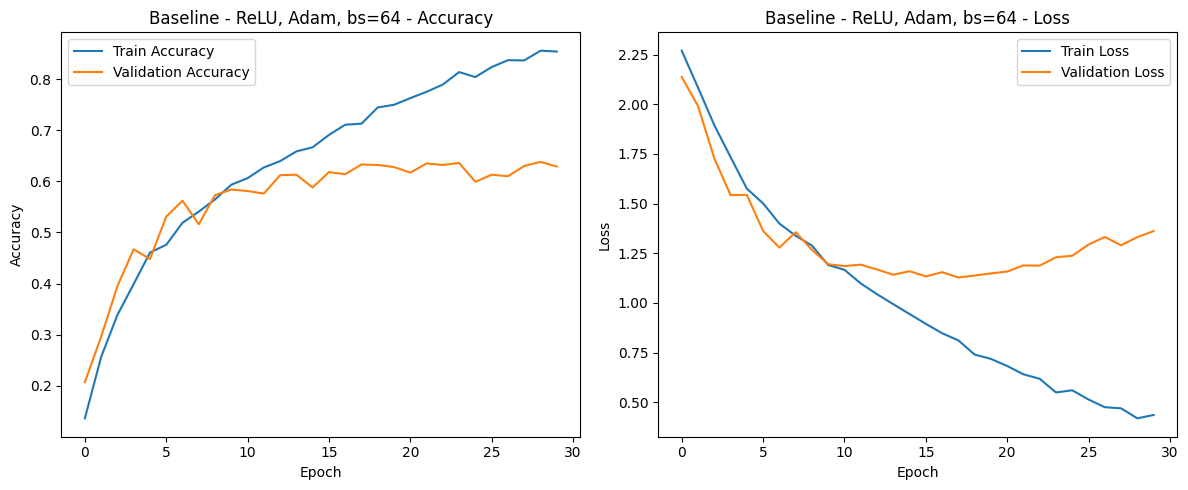

Final test accuracy: 62.90%


In [7]:
model = CNN(activation=nn.ReLU).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

results_baseline = train_model(model, train_loader, test_loader, optimizer, epochs=30)
plot_results(*results_baseline, title='Baseline - ReLU, Adam, bs=64')

## 3. Experiment 1 -- Dense Layer Depth

**Change:** Added a second dense layer (1024 → 512) instead of single (512)
**Hypothesis:** More dense capacity might improve classification
**Result:** 60.5% -- slightly worse than baseline
**Observation:** The bottleneck for image classification is in the convolutional
layers, not the classifier. Larger dense layers add parameters without improving
feature extraction.

Epoch 1/30 | Train acc: 0.0980 | Val acc: 0.1000
Epoch 2/30 | Train acc: 0.0988 | Val acc: 0.1180
Epoch 3/30 | Train acc: 0.1118 | Val acc: 0.1000
Epoch 4/30 | Train acc: 0.1062 | Val acc: 0.1070
Epoch 5/30 | Train acc: 0.1540 | Val acc: 0.2300
Epoch 6/30 | Train acc: 0.2496 | Val acc: 0.3210
Epoch 7/30 | Train acc: 0.3120 | Val acc: 0.4070
Epoch 8/30 | Train acc: 0.3748 | Val acc: 0.4320
Epoch 9/30 | Train acc: 0.3968 | Val acc: 0.4330
Epoch 10/30 | Train acc: 0.4298 | Val acc: 0.4840
Epoch 11/30 | Train acc: 0.4582 | Val acc: 0.4880
Epoch 12/30 | Train acc: 0.4596 | Val acc: 0.5090
Epoch 13/30 | Train acc: 0.4886 | Val acc: 0.5300
Epoch 14/30 | Train acc: 0.5038 | Val acc: 0.5160
Epoch 15/30 | Train acc: 0.5110 | Val acc: 0.5380
Epoch 16/30 | Train acc: 0.5306 | Val acc: 0.5480
Epoch 17/30 | Train acc: 0.5500 | Val acc: 0.5560
Epoch 18/30 | Train acc: 0.5502 | Val acc: 0.5500
Epoch 19/30 | Train acc: 0.5698 | Val acc: 0.5690
Epoch 20/30 | Train acc: 0.5842 | Val acc: 0.5810
Epoch 21/

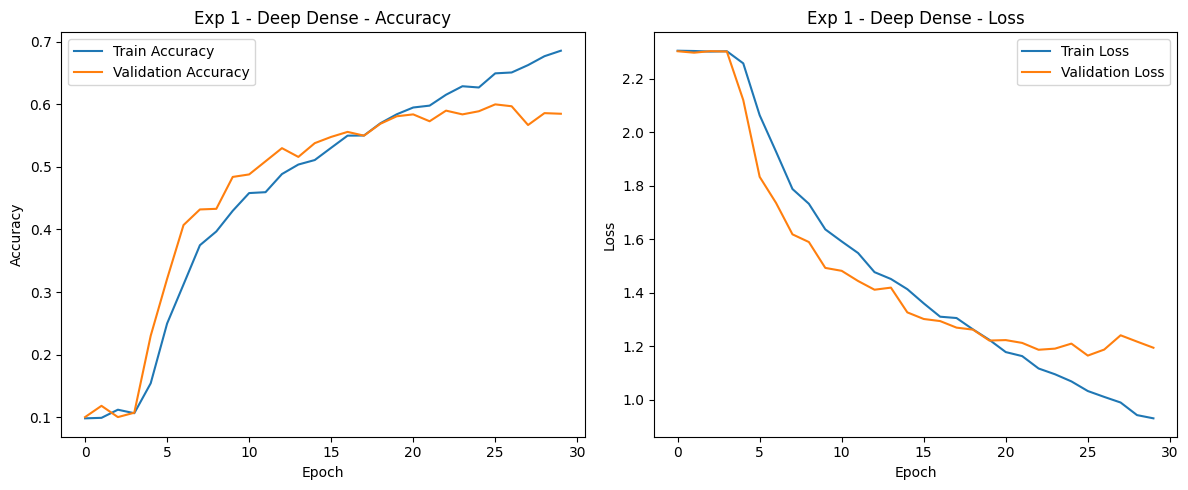

Final test accuracy: 58.50%


In [8]:
class CNN_DeepDense(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, (3, 3), padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, (3, 3), padding=1), nn.ReLU(),
            nn.MaxPool2d((2, 2)), nn.Dropout2d(0.25),
            nn.Conv2d(32, 64, (3, 3), padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, (3, 3), padding=1), nn.ReLU(),
            nn.MaxPool2d((2, 2)), nn.Dropout2d(0.25),
            nn.Conv2d(64, 128, (3, 3), padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, (3, 3), padding=1), nn.ReLU(),
            nn.MaxPool2d((2, 2)), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 1024), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = CNN_DeepDense().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

results_exp1 = train_model(model, train_loader, test_loader, optimizer, epochs=30)
plot_results(*results_exp1, title='Exp 1 - Deep Dense')

## 4. Experiment 2 -- Conv Layer Depth

**Change:** Added 4th conv block with 256 filters
**Hypothesis:** Deeper feature extraction might improve accuracy
**Result:** 54.9% -- significantly worse
**Observation:** 32x32 images are too small for 4 pooling layers.
After 4 MaxPool operations: 32→16→8→4→2px. At 2x2 spatial resolution
the network loses too much spatial information before classification.

Epoch 1/50 | Train acc: 0.1004 | Val acc: 0.1000
Epoch 2/50 | Train acc: 0.0934 | Val acc: 0.0990
Epoch 3/50 | Train acc: 0.1062 | Val acc: 0.1000
Epoch 4/50 | Train acc: 0.1346 | Val acc: 0.1940
Epoch 5/50 | Train acc: 0.1794 | Val acc: 0.1950
Epoch 6/50 | Train acc: 0.2132 | Val acc: 0.2500
Epoch 7/50 | Train acc: 0.2444 | Val acc: 0.2590
Epoch 8/50 | Train acc: 0.2684 | Val acc: 0.2940
Epoch 9/50 | Train acc: 0.2890 | Val acc: 0.3570
Epoch 10/50 | Train acc: 0.3228 | Val acc: 0.3590
Epoch 11/50 | Train acc: 0.3666 | Val acc: 0.4310
Epoch 12/50 | Train acc: 0.4152 | Val acc: 0.4340
Epoch 13/50 | Train acc: 0.4328 | Val acc: 0.4670
Epoch 14/50 | Train acc: 0.4710 | Val acc: 0.4940
Epoch 15/50 | Train acc: 0.4810 | Val acc: 0.5070
Epoch 16/50 | Train acc: 0.4908 | Val acc: 0.4950
Epoch 17/50 | Train acc: 0.5108 | Val acc: 0.5150
Epoch 18/50 | Train acc: 0.5196 | Val acc: 0.5370
Epoch 19/50 | Train acc: 0.5370 | Val acc: 0.5280
Epoch 20/50 | Train acc: 0.5566 | Val acc: 0.5320
Epoch 21/

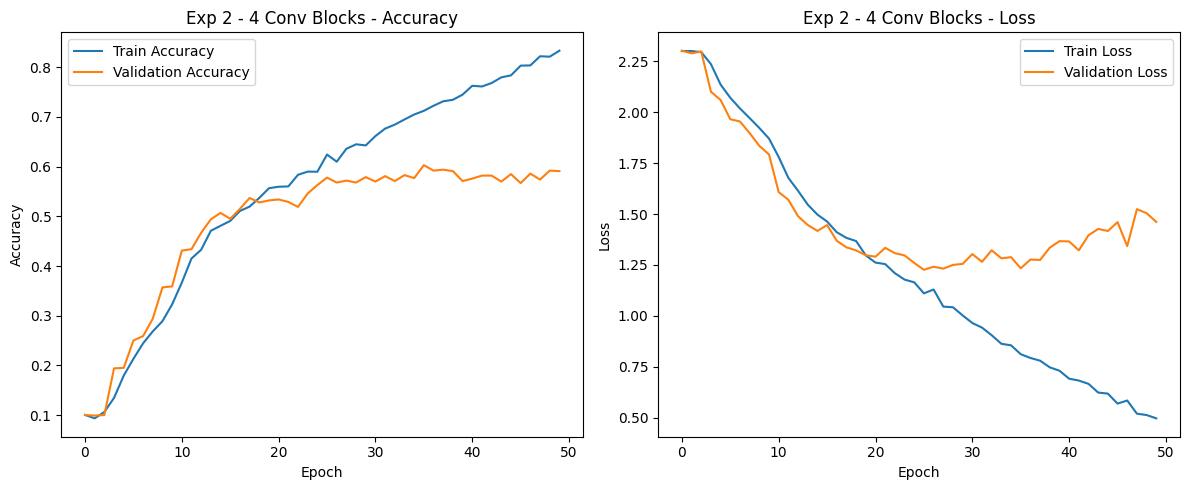

Final test accuracy: 59.10%


In [9]:
class CNN_4Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, (3, 3), padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, (3, 3), padding=1), nn.ReLU(),
            nn.MaxPool2d((2, 2)), nn.Dropout2d(0.25),
            nn.Conv2d(32, 64, (3, 3), padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, (3, 3), padding=1), nn.ReLU(),
            nn.MaxPool2d((2, 2)), nn.Dropout2d(0.25),
            nn.Conv2d(64, 128, (3, 3), padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, (3, 3), padding=1), nn.ReLU(),
            nn.MaxPool2d((2, 2)), nn.Dropout2d(0.25),
            nn.Conv2d(128, 256, (3, 3), padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, (3, 3), padding=1), nn.ReLU(),
            nn.MaxPool2d((2, 2)), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = CNN_4Block().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

results_exp2 = train_model(model, train_loader, test_loader, optimizer, epochs=50)
plot_results(*results_exp2, title='Exp 2 - 4 Conv Blocks')

## 5. Experiment 3 -- Activation Function: LeakyReLU

**Change:** Replaced ReLU with LeakyReLU(0.1) in all layers
**Hypothesis:** LeakyReLU prevents dying neurons by allowing small negative gradients
**Result:** 67.3% -- +5.8% improvement over baseline
**Observation:** ReLU sets all negative inputs to 0, which can permanently
deactivate neurons (dying ReLU problem). LeakyReLU allows a small gradient
(0.1 × input) for negative values, keeping all neurons active throughout training.
This was the single most impactful change in our experiments.

Epoch 1/30 | Train acc: 0.1790 | Val acc: 0.2980
Epoch 2/30 | Train acc: 0.3320 | Val acc: 0.4480
Epoch 3/30 | Train acc: 0.4204 | Val acc: 0.4680
Epoch 4/30 | Train acc: 0.4744 | Val acc: 0.5180
Epoch 5/30 | Train acc: 0.5166 | Val acc: 0.5530
Epoch 6/30 | Train acc: 0.5602 | Val acc: 0.5750
Epoch 7/30 | Train acc: 0.5824 | Val acc: 0.6200
Epoch 8/30 | Train acc: 0.6280 | Val acc: 0.6220
Epoch 9/30 | Train acc: 0.6552 | Val acc: 0.6450
Epoch 10/30 | Train acc: 0.6792 | Val acc: 0.6650
Epoch 11/30 | Train acc: 0.7064 | Val acc: 0.6780
Epoch 12/30 | Train acc: 0.7352 | Val acc: 0.6790
Epoch 13/30 | Train acc: 0.7482 | Val acc: 0.6870
Epoch 14/30 | Train acc: 0.7644 | Val acc: 0.6940
Epoch 15/30 | Train acc: 0.7718 | Val acc: 0.7120
Epoch 16/30 | Train acc: 0.7682 | Val acc: 0.7010
Epoch 17/30 | Train acc: 0.8110 | Val acc: 0.6880
Epoch 18/30 | Train acc: 0.8300 | Val acc: 0.6990
Epoch 19/30 | Train acc: 0.8428 | Val acc: 0.7030
Epoch 20/30 | Train acc: 0.8572 | Val acc: 0.7060
Epoch 21/

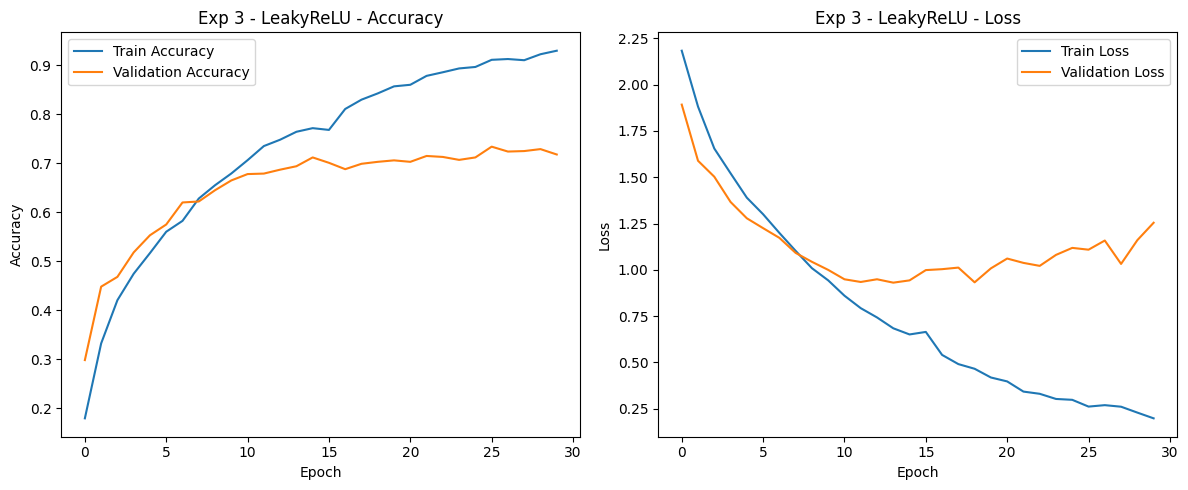

Final test accuracy: 71.80%


In [10]:
model = CNN(activation=lambda: nn.LeakyReLU(0.1)).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

results_exp3 = train_model(model, train_loader, test_loader, optimizer, epochs=30)
plot_results(*results_exp3, title='Exp 3 - LeakyReLU')

## 6. Experiment 4 -- Optimizer: SGD vs Adam

**Change:** Replaced Adam (lr=0.001) with SGD (lr=0.01, momentum=0.9)
**Hypothesis:** SGD with momentum might find better generalizing minima
**Result:** 55.3% at 30 epochs, 59.2% at 80 epochs -- both below Adam
**Observation:** Adam uses adaptive per-parameter learning rates, converging
much faster than SGD. SGD requires more epochs and careful learning rate tuning.
Adam reached 67% in 30 epochs while SGD needed 80 epochs to reach 59%.
For this dataset and architecture, Adam is clearly superior.

Epoch 1/30 | Train acc: 0.0992 | Val acc: 0.1000
Epoch 2/30 | Train acc: 0.0978 | Val acc: 0.1000
Epoch 3/30 | Train acc: 0.0958 | Val acc: 0.1100
Epoch 4/30 | Train acc: 0.0978 | Val acc: 0.1000
Epoch 5/30 | Train acc: 0.1020 | Val acc: 0.1090
Epoch 6/30 | Train acc: 0.1028 | Val acc: 0.1060
Epoch 7/30 | Train acc: 0.1174 | Val acc: 0.1350
Epoch 8/30 | Train acc: 0.1566 | Val acc: 0.2180
Epoch 9/30 | Train acc: 0.2244 | Val acc: 0.2710
Epoch 10/30 | Train acc: 0.2822 | Val acc: 0.3430
Epoch 11/30 | Train acc: 0.3078 | Val acc: 0.3850
Epoch 12/30 | Train acc: 0.3478 | Val acc: 0.3990
Epoch 13/30 | Train acc: 0.3826 | Val acc: 0.4530
Epoch 14/30 | Train acc: 0.4030 | Val acc: 0.4410
Epoch 15/30 | Train acc: 0.4196 | Val acc: 0.4820
Epoch 16/30 | Train acc: 0.4498 | Val acc: 0.5090
Epoch 17/30 | Train acc: 0.4788 | Val acc: 0.5110
Epoch 18/30 | Train acc: 0.4930 | Val acc: 0.5280
Epoch 19/30 | Train acc: 0.5202 | Val acc: 0.5230
Epoch 20/30 | Train acc: 0.5324 | Val acc: 0.5610
Epoch 21/

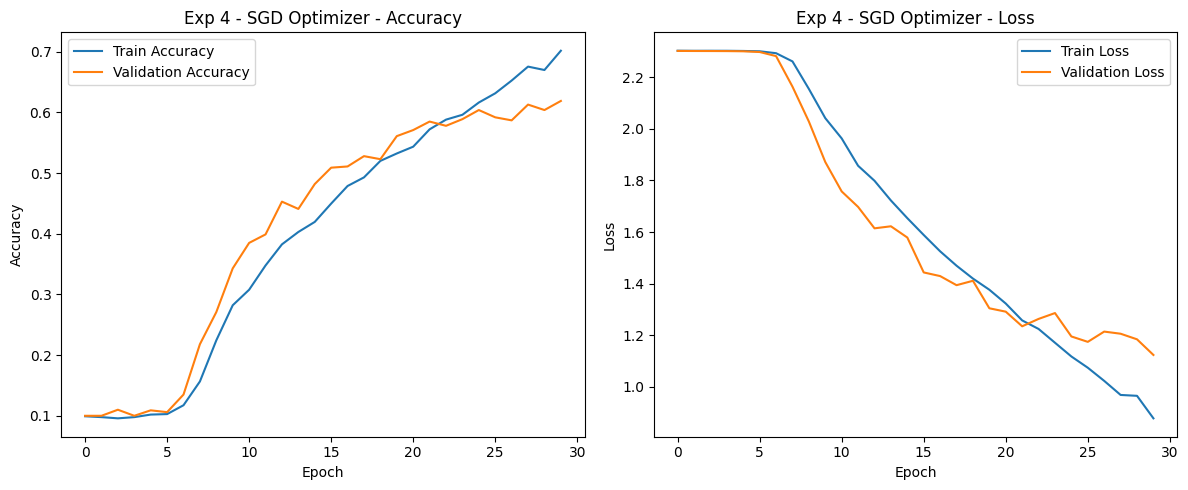

Final test accuracy: 61.90%


In [11]:
model = CNN(activation=lambda: nn.LeakyReLU(0.1)).to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

results_exp4 = train_model(model, train_loader, test_loader, optimizer, epochs=30)
plot_results(*results_exp4, title='Exp 4 - SGD Optimizer')

## 7. Experiment 5 -- Batch Size

**Changes tested:** batch_size = 128, 32 (baseline was 64)
**Hypothesis:** Smaller batches introduce gradient noise acting as implicit regularization
**Results:**
- batch_size=128: 68.0%
- batch_size=32: 71.0% (best result)
**Observation:** Smaller batch sizes update weights more frequently per epoch
with noisier gradient estimates. This noise helps escape sharp minima and
find flatter solutions that generalize better. batch_size=32 gave our best result.

Epoch 1/30 | Train acc: 0.1696 | Val acc: 0.2930
Epoch 2/30 | Train acc: 0.3316 | Val acc: 0.3750
Epoch 3/30 | Train acc: 0.4076 | Val acc: 0.4460
Epoch 4/30 | Train acc: 0.4502 | Val acc: 0.4750
Epoch 5/30 | Train acc: 0.4944 | Val acc: 0.5380
Epoch 6/30 | Train acc: 0.5114 | Val acc: 0.5470
Epoch 7/30 | Train acc: 0.5488 | Val acc: 0.5460
Epoch 8/30 | Train acc: 0.5658 | Val acc: 0.5820
Epoch 9/30 | Train acc: 0.5872 | Val acc: 0.6020
Epoch 10/30 | Train acc: 0.6158 | Val acc: 0.6110
Epoch 11/30 | Train acc: 0.6370 | Val acc: 0.6050
Epoch 12/30 | Train acc: 0.6470 | Val acc: 0.6220
Epoch 13/30 | Train acc: 0.6740 | Val acc: 0.6390
Epoch 14/30 | Train acc: 0.6944 | Val acc: 0.6500
Epoch 15/30 | Train acc: 0.7130 | Val acc: 0.6580
Epoch 16/30 | Train acc: 0.7404 | Val acc: 0.6610
Epoch 17/30 | Train acc: 0.7446 | Val acc: 0.6600
Epoch 18/30 | Train acc: 0.7724 | Val acc: 0.6670
Epoch 19/30 | Train acc: 0.7872 | Val acc: 0.6800
Epoch 20/30 | Train acc: 0.8128 | Val acc: 0.6730
Epoch 21/

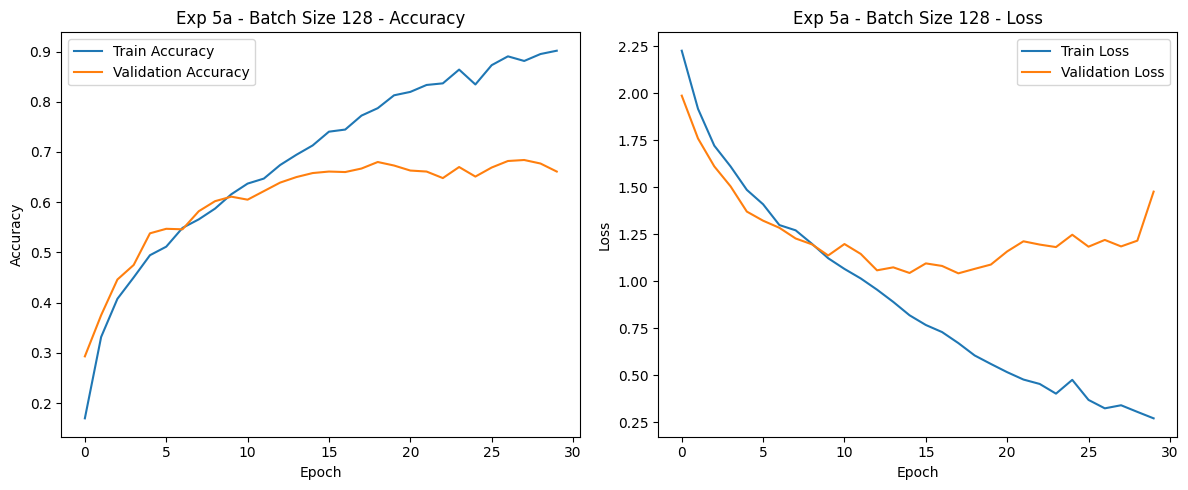

Final test accuracy: 66.10%


In [12]:
model = CNN(activation=lambda: nn.LeakyReLU(0.1)).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=128, shuffle=False)

results_exp5a = train_model(model, train_loader, test_loader, optimizer, epochs=30)
plot_results(*results_exp5a, title='Exp 5a - Batch Size 128')

Epoch 1/30 | Train acc: 0.2064 | Val acc: 0.3300
Epoch 2/30 | Train acc: 0.3796 | Val acc: 0.4540
Epoch 3/30 | Train acc: 0.4612 | Val acc: 0.4990
Epoch 4/30 | Train acc: 0.5052 | Val acc: 0.5440
Epoch 5/30 | Train acc: 0.5438 | Val acc: 0.5760
Epoch 6/30 | Train acc: 0.5874 | Val acc: 0.5810
Epoch 7/30 | Train acc: 0.6174 | Val acc: 0.5950
Epoch 8/30 | Train acc: 0.6434 | Val acc: 0.6440
Epoch 9/30 | Train acc: 0.6754 | Val acc: 0.6610
Epoch 10/30 | Train acc: 0.7028 | Val acc: 0.6760
Epoch 11/30 | Train acc: 0.7252 | Val acc: 0.6660
Epoch 12/30 | Train acc: 0.7576 | Val acc: 0.6780
Epoch 13/30 | Train acc: 0.7634 | Val acc: 0.6840
Epoch 14/30 | Train acc: 0.7870 | Val acc: 0.6760
Epoch 15/30 | Train acc: 0.8114 | Val acc: 0.6960
Epoch 16/30 | Train acc: 0.8286 | Val acc: 0.6790
Epoch 17/30 | Train acc: 0.8394 | Val acc: 0.6760
Epoch 18/30 | Train acc: 0.8562 | Val acc: 0.6660
Epoch 19/30 | Train acc: 0.8624 | Val acc: 0.6930
Epoch 20/30 | Train acc: 0.8814 | Val acc: 0.7010
Epoch 21/

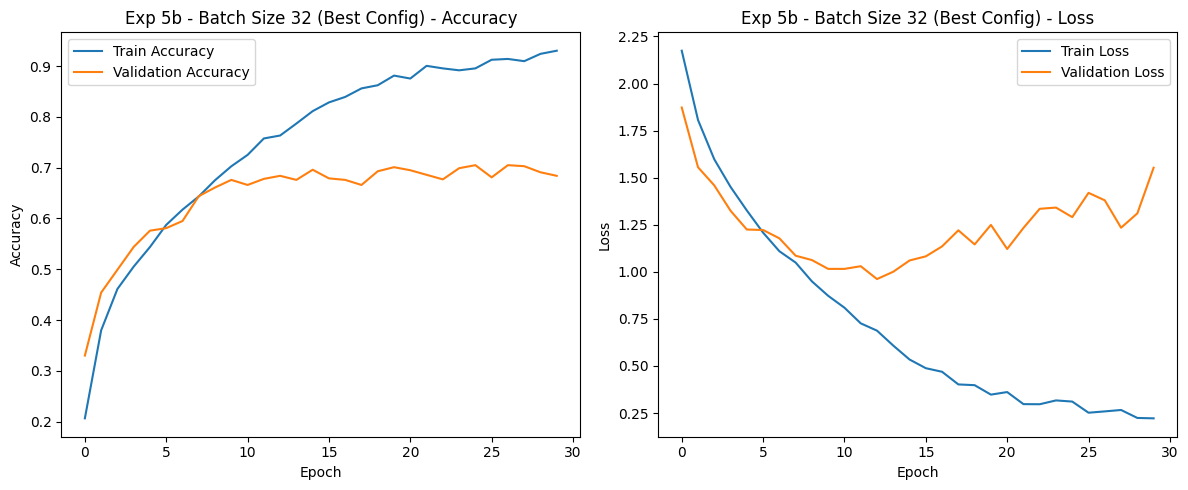

Final test accuracy: 68.40%


In [13]:
model = CNN(activation=lambda: nn.LeakyReLU(0.1)).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

results_exp5b = train_model(model, train_loader, test_loader, optimizer, epochs=30)
plot_results(*results_exp5b, title='Exp 5b - Batch Size 32 (Best Config)')

## 8. Experiment 6 -- Second Dataset: Visually Similar Animal Classes

**Classes:** bear, chimpanzee, crocodile, elephant, kangaroo, leopard, lion, tiger, wolf, seal
**Indices:** [3, 21, 27, 31, 38, 42, 43, 88, 97, 72]
**Hypothesis:** Visually similar classes should be harder to classify than diverse classes
**Best config applied:** LeakyReLU, Adam lr=0.001, batch_size=32, 30 epochs
**Result:** 59.1% vs 71.0% on dataset 1 -- 12% lower
**Observation:** Same model and hyperparameters perform significantly worse on
visually similar classes. A leopard and lion share similar textures, colors,
and shapes, making them harder to separate than an apple and a bicycle.
This confirms that dataset difficulty is as important as hyperparameter choice.

In [14]:
# Reload and filter to animal classes
X_train2 = np.array(trainset.data)
y_train2 = np.array(trainset.targets)
X_test2 = np.array(testset.data)
y_test2 = np.array(testset.targets)

selected_classes2 = [3, 21, 27, 31, 38, 42, 43, 88, 97, 72]
class_names2 = ['bear', 'chimpanzee', 'crocodile', 'elephant', 'kangaroo',
                'leopard', 'lion', 'tiger', 'wolf', 'seal']

train_mask2 = np.isin(y_train2, selected_classes2)
X_train2, y_train2 = X_train2[train_mask2], y_train2[train_mask2]
test_mask2 = np.isin(y_test2, selected_classes2)
X_test2, y_test2 = X_test2[test_mask2], y_test2[test_mask2]

label_map2 = {orig: new for new, orig in enumerate(selected_classes2)}
y_train2 = np.array([label_map2[l] for l in y_train2])
y_test2 = np.array([label_map2[l] for l in y_test2])

X_train2 = X_train2.astype('float32') / 255.0
X_test2 = X_test2.astype('float32') / 255.0

X_train2_t = torch.tensor(X_train2).permute(0, 3, 1, 2)
y_train2_t = torch.tensor(y_train2, dtype=torch.long)
X_test2_t = torch.tensor(X_test2).permute(0, 3, 1, 2)
y_test2_t = torch.tensor(y_test2, dtype=torch.long)

train_loader2 = DataLoader(TensorDataset(X_train2_t, y_train2_t), batch_size=32, shuffle=True)
test_loader2 = DataLoader(TensorDataset(X_test2_t, y_test2_t), batch_size=32, shuffle=False)

print(f"Dataset 2 training samples: {len(X_train2)}")

Dataset 2 training samples: 5000


Epoch 1/30 | Train acc: 0.1324 | Val acc: 0.2390
Epoch 2/30 | Train acc: 0.2284 | Val acc: 0.2960
Epoch 3/30 | Train acc: 0.2806 | Val acc: 0.2810
Epoch 4/30 | Train acc: 0.3050 | Val acc: 0.3100
Epoch 5/30 | Train acc: 0.3466 | Val acc: 0.3350
Epoch 6/30 | Train acc: 0.3796 | Val acc: 0.4140
Epoch 7/30 | Train acc: 0.4118 | Val acc: 0.4570
Epoch 8/30 | Train acc: 0.4358 | Val acc: 0.4510
Epoch 9/30 | Train acc: 0.4664 | Val acc: 0.4970
Epoch 10/30 | Train acc: 0.5002 | Val acc: 0.5030
Epoch 11/30 | Train acc: 0.5280 | Val acc: 0.5080
Epoch 12/30 | Train acc: 0.5512 | Val acc: 0.5320
Epoch 13/30 | Train acc: 0.5820 | Val acc: 0.5300
Epoch 14/30 | Train acc: 0.6064 | Val acc: 0.5290
Epoch 15/30 | Train acc: 0.6242 | Val acc: 0.5530
Epoch 16/30 | Train acc: 0.6510 | Val acc: 0.5560
Epoch 17/30 | Train acc: 0.6744 | Val acc: 0.5650
Epoch 18/30 | Train acc: 0.6982 | Val acc: 0.5600
Epoch 19/30 | Train acc: 0.7052 | Val acc: 0.5720
Epoch 20/30 | Train acc: 0.7298 | Val acc: 0.5700
Epoch 21/

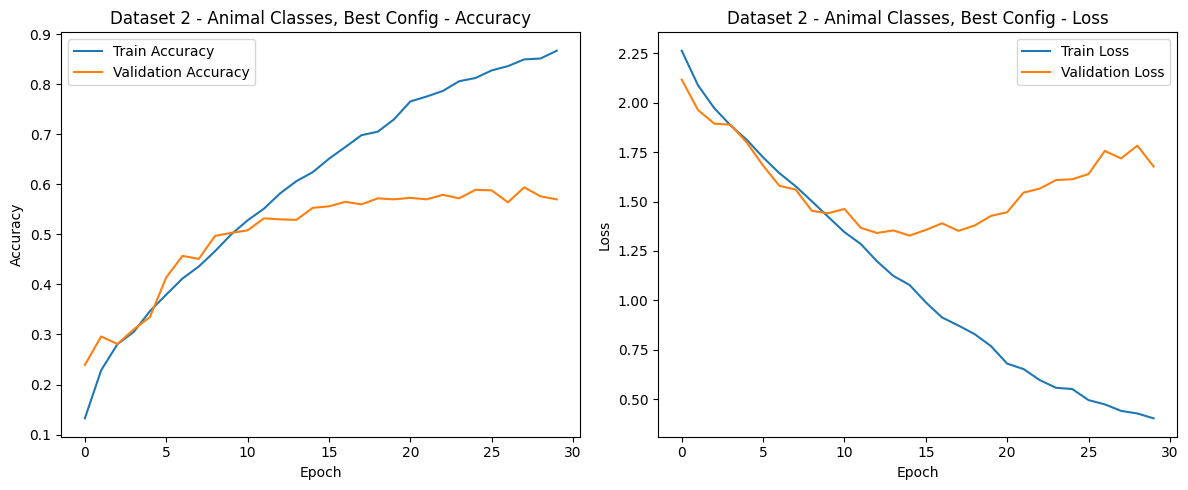

Final test accuracy: 57.00%


In [15]:
model = CNN(activation=lambda: nn.LeakyReLU(0.1)).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

results_dataset2 = train_model(model, train_loader2, test_loader2, optimizer, epochs=30)
plot_results(*results_dataset2, title='Dataset 2 - Animal Classes, Best Config')

## 9. Summary of Results

| Experiment | Change | Val Accuracy |
|------------|--------|-------------|
| Baseline | ReLU, Adam, bs=64, 30ep | 61.5% |
| Exp 1 | Deeper dense (1024→512) | 60.5% |
| Exp 2 | 4 conv blocks, 50ep | 54.9% |
| Exp 3 | LeakyReLU + Adam | 67.3% |
| Exp 4a | SGD lr=0.01, 30ep | 55.3% |
| Exp 4b | SGD lr=0.01, 80ep | 59.2% |
| Exp 5a | LeakyReLU + Adam, bs=128 | 68.0% |
| Exp 5b | LeakyReLU + Adam, bs=32 | 71.0% (best) |
| Dataset 2 | Animal classes, best config | 59.1% |

**Key findings:**
- Most impactful change: activation function (LeakyReLU +5.8%)
- Deeper conv blocks hurt on small 32x32 images
- Adam consistently outperformed SGD in convergence speed
- Smaller batch sizes improved generalization
- Visually similar classes are significantly harder to classify